# Most Signatures Cube

The puzzle with most bandage shapes. Explore its complete shape graph, extract
legal shape-loop generators, and use GAP to count colored states exactly.

Select the **v2/.venv** Python kernel. Group analysis requires an external
[GAP installation](https://www.gap-system.org/): put `gap` on `PATH`, or set
`GAP_EXECUTABLE` below to your executable's path. Loop extraction itself does
not require GAP.

In [1]:
import sys
from html import escape

import bce_v2 as c
import matplotlib.pyplot as plt
from IPython.display import HTML, display

%matplotlib inline
print("Python kernel:", sys.executable)

GAP_EXECUTABLE = "gap"  # Or an absolute path to your GAP executable.

Python kernel: /home/ladislav/prj/nonvl/bandaged-cube-explorer/v2/.venv/bin/python


## Define the puzzle

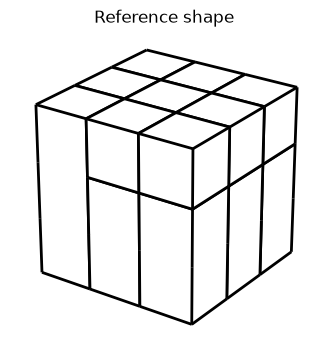

In [2]:
msc = [
      0, 0, 0,
     0, 0, 0,
    1, 0, 0,
      7, 6, 5,
     8, 0, 4,
    1, 2, 3,
      7, 6, 5,
     8, 0, 4,
    1, 2, 3,
]

initial = c.Shape(msc)
figure = c.draw_cubes(initial)
figure.axes[0].set_title("Reference shape")
plt.show()


## Explore the shapes graph

In [8]:
graph = c.explore(initial, metric="QTM")
assert graph.complete

{
    "shapes": len(graph),
    "clockwise_arcs": len(graph.arcs),
    "metric": graph.metric,
    "complete": graph.complete,
}


{'shapes': 92176, 'clockwise_arcs': 154272, 'metric': 'QTM', 'complete': True}

## Shape loops and colored-state counts

A spanning tree gives a path from the reference shape to every other shape.
Each remaining clockwise arc gives a legal loop: follow the tree to that arc,
traverse it, and return along the tree. With `n` shapes and `m` clockwise arcs,
there are `m - n + 1` candidates. Their colored actions generate the complete
isotropy group at the reference shape.

First remove identity actions and duplicate permutations up to inverse. GAP
then computes the exact group order and selects a smaller generating subset
while retaining the original move witnesses. The subset need not have minimum
cardinality. This calculation uses permutations of 48 movable stickers and
does not enumerate the colored graph.

In [9]:
loops = graph.isotropy_loops()
assert loops.root_shape == initial
assert loops.shape_count == len(graph)
assert loops.candidate_count == loops.arc_count - loops.shape_count + 1

extraction_rows = [
    ("Shapes (fixed frame)", loops.shape_count),
    ("Clockwise arcs", loops.arc_count),
    ("Candidate loops", loops.candidate_count),
    ("Nonidentity candidates", loops.nonidentity_count),
    ("Generators after removing identities and duplicates up to inverse", len(loops)),
]
display(HTML(
    "<table><thead><tr><th>Loop extraction</th><th>Count</th></tr></thead><tbody>"
    + "".join(f"<tr><td>{escape(label)}</td><td>{count:,}</td></tr>"
              for label, count in extraction_rows)
    + "</tbody></table>"
))

Loop extraction,Count
Shapes (fixed frame),"92,176"
Clockwise arcs,"154,272"
Candidate loops,"62,097"
Nonidentity candidates,"25,118"
Generators after removing identities and duplicates up to inverse,"3,336"


In [10]:
analysis = loops.analyze(gap_executable=GAP_EXECUTABLE)
assert analysis.colored_state_count == len(graph) * analysis.group_order

analysis_rows = [
    ("Reduced witnessed generators", len(analysis.generators)),
    ("Isotropy group order (colored states per shape)", analysis.group_order),
    ("Reachable colored states", analysis.colored_state_count),
]
print("Algebra backend: GAP", analysis.gap_version)
display(HTML(
    "<table><thead><tr><th>Exact analysis</th><th>Count</th></tr></thead><tbody>"
    + "".join(f"<tr><td>{escape(label)}</td><td>{count:,}</td></tr>"
              for label, count in analysis_rows)
    + "</tbody></table>"
))

Algebra backend: GAP 4.12.1


Exact analysis,Count
Reduced witnessed generators,4
Isotropy group order (colored states per shape),"10,368"
Reachable colored states,"955,680,768"


Every shape in this fixed-frame component has exactly `analysis.group_order`
reachable colored states above it. The total is therefore
`len(graph) * analysis.group_order`. The count retains full cubie identities and
orientations; center spin is excluded. It is an exact component size, without
storing all colored states. Rotation-quotiented shape counts cannot be used in
this multiplication.

## Reduced generators and their legal loops

Each row is an actual loop at the reference shape. The generator ID identifies
its original clockwise graph arc; source and target are shape vertex IDs. QTM
length counts the quarter turns in the displayed witness, before simplification.
Replay checks below verify both shape restoration and the full sticker action.

In [7]:
reference = c.State(loops.root_shape)
generator_rows = []
for generator in analysis.generators:
    witness = generator.moves
    replayed = reference.apply(witness)
    assert replayed.shape == loops.root_shape
    assert replayed.sticker_permutation == generator.permutation
    assert sum(2 if move.endswith("2") else 1 for move in witness.split()) == generator.qtm_length
    generator_rows.append(
        f"<tr><td>{generator.id}</td><td>{generator.source} → {generator.target}</td>"
        f"<td>{generator.qtm_length}</td><td><code>{escape(witness)}</code></td></tr>"
    )

display(HTML(
    "<table><thead><tr><th>Generator ID</th><th>Shape arc</th>"
    "<th>QTM length</th><th>Legal move witness</th></tr></thead><tbody>"
    + "".join(generator_rows) + "</tbody></table>"
))
print(f"Verified all {len(analysis.generators)} reduced generator witnesses.")

Generator ID,Shape arc,QTM length,Legal move witness
1048,445 → 243,6,F' B' U U B F
525,220 → 289,9,F U U F' U L' U' U' L
2126,902 → 1589,14,L U L' B B R B R' F' U' U' B U' F
5851,2603 → 3607,14,L U L' B' R B L U' U' L' R' F' U F


Verified all 4 reduced generator witnesses.


## Solve a colored scramble

Edit the short legal scramble below to try an individual colored solution.
This bounded direct search is separate from the algebraic loop solver
demonstrated below. A search cutoff does not imply that a
scramble is unreachable.

Scramble: R L U
Colored-state hex ID: 0000000003de40010e07141605100b06100214160a120e08040c00


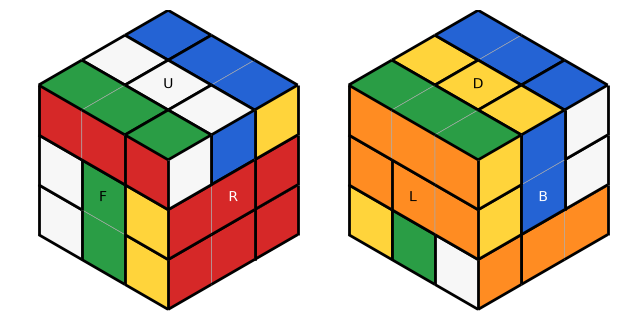

In [3]:
scramble = "R L U"
colored_state = c.State(initial).apply(scramble)
print("Scramble:", scramble)
print("Colored-state hex ID:", colored_state.hex_id)
figure = c.draw_cubes(colored_state, colors=True, views=("UFR", "BLD"))
plt.show()

In [4]:
result = c.solve_colored(
    colored_state, metric="HTM", max_states=100_000, max_depth=12
)
print("Status:", result.status)
if result.status == "solved":
    print("Shortest solution:", result.solution or "(already solved)")
    print("Move count (HTM):", result.distance)
    assert colored_state.apply(result.solution).is_solved
elif result.status == "limit_reached":
    print("Search cutoff:", result.stop_reason)

Status: solved
Shortest solution: U' R' L'
Move count (HTM): 3


## Solve through the reusable loop library

Reuse the exact group analysis to prepare one `LoopSolver` for many scrambles.
The same numbered base algorithms are shared across solves; inverses and powers
refer to that library instead of introducing new algorithms to memorize. GAP
prefers a small subset of these algorithms for the current residual, without
promising the minimum repertoire or a shortest face-turn solution. Only the
shape graph and permutation-group data are needed, so the colored graph need
not fit in memory. A complete human solving method remains future work.

For a nontrivial color residual, prepend two legal reference-shape loops to the
short scramble already used above. Reimport its facelets to discard all move
history. The result separates shape restoration from the compact loop
expression, reports the distinct algorithms and both move costs, and checks
legal replay. The 100,000-turn expansion cap bounds the physical witness;
the 60-second timeout applies separately to GAP calls.


In [11]:
loop_solver = c.LoopSolver(analysis, gap_executable=GAP_EXECUTABLE, timeout=60)

# Add color changes at the reference shape, then replay the existing scramble.
loop_demo = c.State(initial)
for algorithm in loop_solver.generators[:2]:
    loop_demo = loop_demo.apply(algorithm.moves)
loop_demo = loop_demo.apply(scramble)
loop_imported = c.State.from_facelets(loop_demo.facelets, initial)
assert loop_imported.scramble is None

loop_result = loop_solver.solve(
    loop_imported, metric="HTM", max_expanded_moves=100_000
)
if loop_result.status == "solved":
    assert loop_imported.apply(loop_result.solution).is_solved
elif loop_result.status == "limit_reached":
    print("Expansion stopped:", loop_result.stop_reason)

display({
    "status": loop_result.status,
    "scramble_history": loop_imported.scramble,
    "shape_restoration": loop_result.shape_solution,
    "loop_expression": loop_result.expression or "(no loop steps)",
    "base_algorithms": [f"L{algorithm.id}" for algorithm in loop_result.algorithms],
    "distinct_algorithms": loop_result.algorithm_count,
    "QTM_cost": loop_result.qtm_length,
    "HTM_cost": loop_result.htm_length,
    "unsimplified_QTM_expansion": loop_result.required_expanded_moves,
})


{'status': 'solved',
 'scramble_history': None,
 'shape_restoration': "U R' L'",
 'loop_expression': 'L525^-1',
 'base_algorithms': ['L525'],
 'distinct_algorithms': 1,
 'QTM_cost': 12,
 'HTM_cost': 9,
 'unsimplified_QTM_expansion': 12}